In [1]:
import numpy as np
import functions as fn
from tensorflow import keras as ks
from tqdm import tqdm
import matplotlib.pyplot as plt
model = ks.models.load_model('cii_model_silva.h5')

In [2]:
par=np.loadtxt('data/params_t')
par_og=np.loadtxt('data/params_LH.txt')
dpk=np.loadtxt('data/cii_dpk_silva')
k=np.loadtxt('data/k.txt')
nbins=np.loadtxt('data/nbins.txt')

# 1. Comparison plot

In [3]:
ind=np.random.randint(low=0,high=len(par),size=9)
params_test=par[ind]
dpk_test=dpk[ind]

In [4]:
sv=np.empty((9,6))
for i in range(len(ind)):
    for j in range(len(dpk_test[0])):
        sv[i,j]=dpk_test[i,j]/nbins[j]

In [5]:
dpk_pred=[]
for el in tqdm(params_test):
    par_m = np.reshape(el, (1, 2))
    cii=model.predict(par_m,verbose=0)[0]
    cii=np.exp(15*cii)
    dpk_pred.append(np.array(cii))

100%|██████████| 9/9 [00:00<00:00, 22.49it/s]


In [6]:
params_test=par_og[ind]

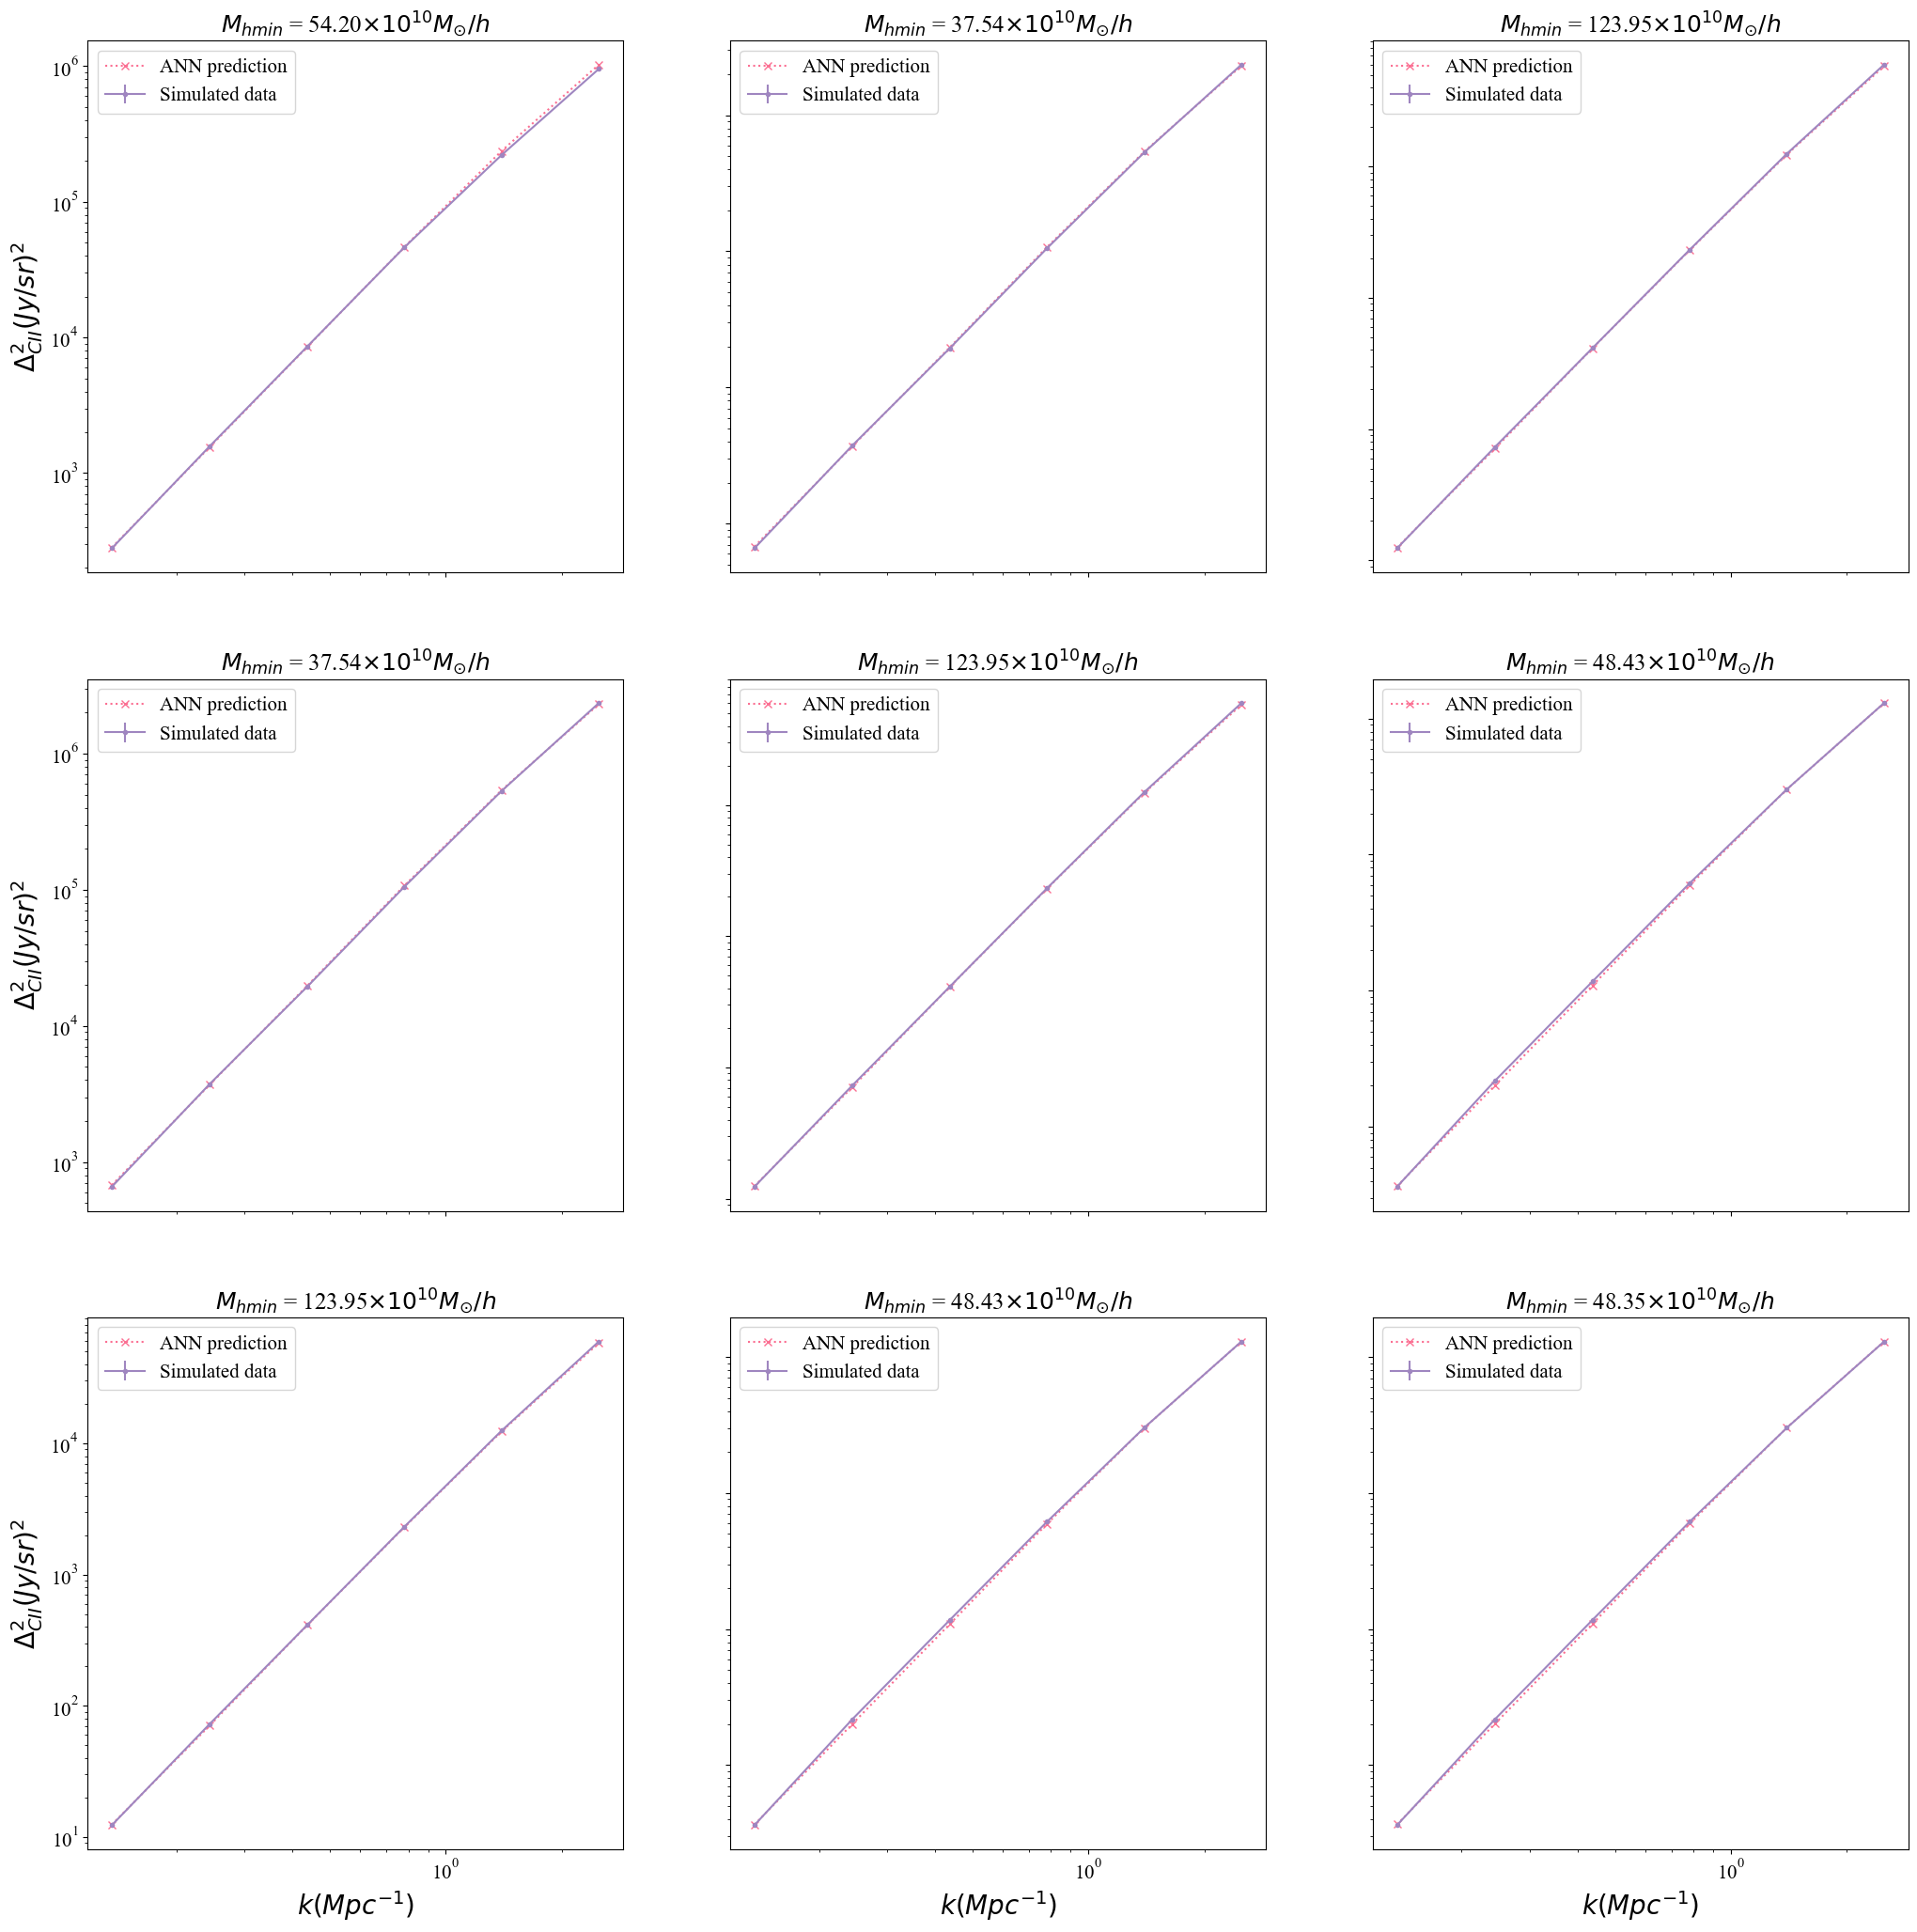

In [12]:
import matplotlib as mpl

# Set the font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size']=15
fig,axs=plt.subplots(3,3,figsize=(25,25))

for i in range(3):
    for j in range(3):
        axs[i,j].set_title(r'$ M_{hmin} $ = '+"{:.2f}".format(params_test[int(i+j),0])+r'$ \times 10^{10} M_{\odot}/h $')

for ax in axs.flat:
    ax.set_xlabel(r'$k (Mpc^{-1})$',fontsize=20)
    ax.set_ylabel(r'$ \Delta^2_{CII} (Jy/sr)^2$',fontsize=20)

for i in range(3):
    for j in range(3):
        axs[i,j].set_xscale('log')
        axs[i,j].set_yscale('log')
        axs[i,j].plot(k,dpk_pred[int(i+j)],label='ANN prediction',ls='dotted',c='#fb6f92',marker='x')
        axs[i,j].errorbar(k,dpk_test[int(i+j)],label='Simulated data',c='#9f86c0',xerr=None,yerr=sv[int(i+j)],marker='.')

for ax in axs.flat:
    ax.label_outer()
    ax.legend(loc='best')

plt.savefig("figures/comparison_plot.pdf",bbox_inches='tight',dpi=300)

# 2. History plot

In [9]:
# Load the history
history_array = np.load('cii_history_silva.npy', allow_pickle=True)

# Access the first (and only) item in the array to get the dictionary
history_dict = history_array.item()

# Now you can access the data in the dictionary
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['root_mean_squared_error']
val_accuracy = history_dict['val_root_mean_squared_error']

# Continue with your processing...


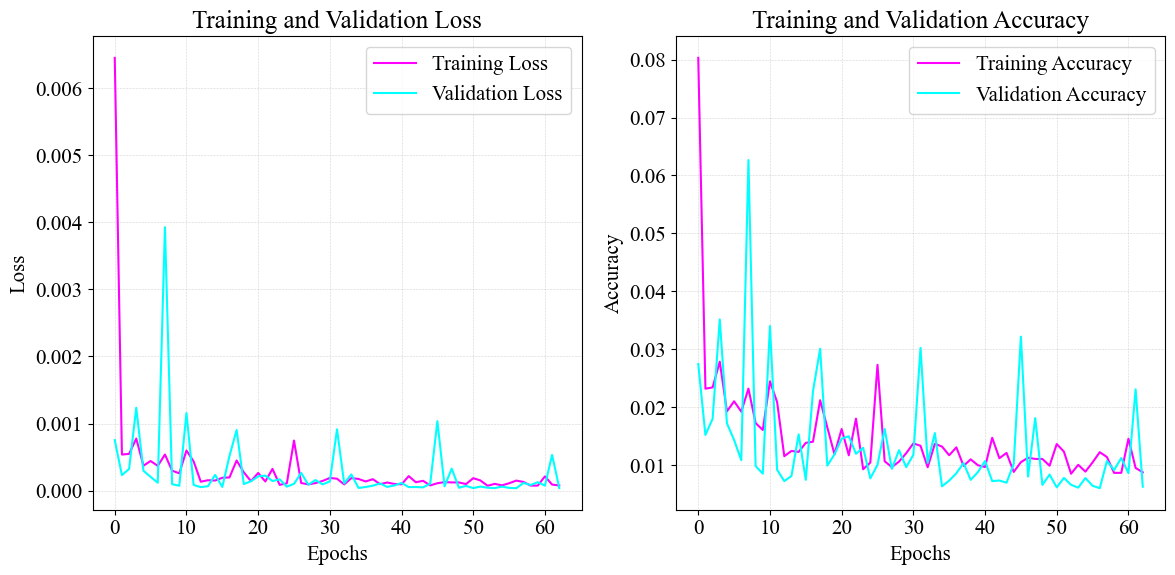

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set the font and font size
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size']=15

# Plot training and validation loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(loss, label='Training Loss',c='magenta')
plt.plot(val_loss, label='Validation Loss',c='cyan')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(ls='dotted',lw=0.4)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(accuracy, label='Training Accuracy',c='magenta')
plt.plot(val_accuracy, label='Validation Accuracy',c='cyan')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.grid(ls='dotted',lw=0.4)
plt.tight_layout()

plt.savefig("figures/history.pdf",bbox_inches='tight',dpi=300)